<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/06_Advanced_Logistic_Regression_and_Extensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Advanced Logistic Regression and Extensions

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 6 membahas logistic regression secara mendalam, termasuk konsep-konsep lanjutan seperti klasifikasi multiclass, multilabel, regularisasi dalam logistic regression, dan metrik evaluasi model klasifikasi. Meskipun nama "regression" terdengar seperti tugas prediksi nilai kontinu, logistic regression sebenarnya adalah alat yang sangat kuat untuk masalah **klasifikasi**, di mana tujuannya adalah memprediksi keanggotaan kategori atau kelas.

### Topik yang Dibahas:
1. Overview logistic regression (binary classification)
2. Teknik klasifikasi multiclass (OvR dan Multinomial)
3. Regularisasi dalam logistic regression (L1 dan L2)
4. Konsep multilabel classification
5. Metrik evaluasi model: Accuracy, Precision, Recall, F1, ROC-AUC
6. Implementasi komprehensif dalam scikit-learn


---
## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")


Library berhasil diimport.


---
## 1. Overview Logistic Regression

### Penjelasan Teori

**Logistic regression** adalah metode statistik fundamental yang digunakan untuk masalah **binary classification**, yaitu ketika target hanya memiliki dua kemungkinan nilai (0 atau 1, Ya atau Tidak, Malignant atau Benign, dst.).

Berbeda dari linear regression yang memprediksi nilai kontinu, logistic regression memprediksi **probabilitas** bahwa suatu input termasuk dalam kelas tertentu. Ini dicapai dengan menerapkan **logistic function** (atau sigmoid function) pada kombinasi linear dari fitur input:

```
P(Y=1|X) = 1 / (1 + e^(-(beta_0 + beta_1*X_1 + ... + beta_n*X_n)))
```

**Sigmoid function** mengubah nilai dari rentang (-inf, +inf) menjadi (0, 1), yang dapat diinterpretasikan sebagai probabilitas.

**Decision boundary:** Secara default, jika probabilitas >= 0.5, prediksi kelas 1; jika < 0.5, prediksi kelas 0. Threshold ini bisa disesuaikan tergantung kebutuhan (misalnya, untuk mendeteksi penyakit langka, mungkin ingin threshold lebih rendah untuk mengurangi false negatives).

**Log-odds (Logit):**
Log-odds adalah logaritma natural dari odds, di mana odds = P / (1 - P). Logistic regression sebenarnya memodelkan log-odds sebagai fungsi linear dari fitur:
```
log(P / (1-P)) = beta_0 + beta_1*X_1 + ... + beta_n*X_n
```
Transformasi ini mengubah skala probabilitas (0 hingga 1) menjadi skala linear yang tidak terbatas (dari negatif hingga positif tak hingga).


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler

# Load Breast Cancer dataset (binary classification)
data = load_breast_cancer()
X_bc = data.data
y_bc = data.target
feature_names_bc = data.feature_names
class_names = ['Malignant', 'Benign']

df_bc = pd.DataFrame(X_bc, columns=feature_names_bc)
df_bc['target'] = y_bc

print(f"Shape dataset: {df_bc.shape}")
print(f"Distribusi kelas:")
print(df_bc['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
print(f"5 baris pertama (5 fitur pertama):")
display(df_bc[list(feature_names_bc[:5]) + ['target']].head())


Shape dataset: (569, 31)
Distribusi kelas:
target
Benign       357
Malignant    212
Name: count, dtype: int64
5 baris pertama (5 fitur pertama):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,target
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


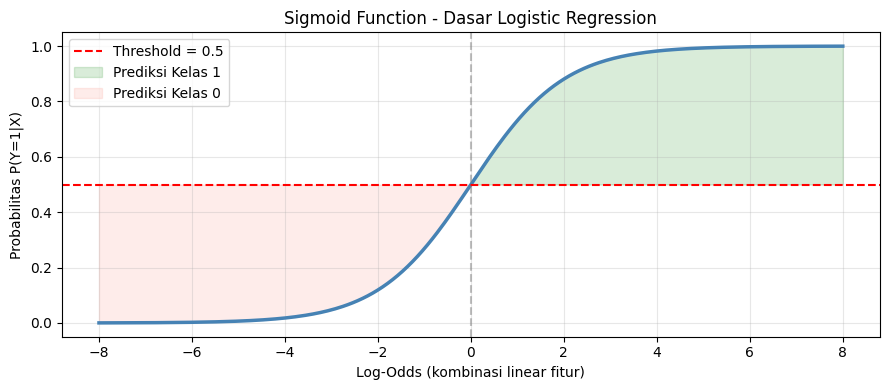

In [4]:
# Visualisasi sigmoid function
x_sig = np.linspace(-8, 8, 300)
y_sig = 1 / (1 + np.exp(-x_sig))

plt.figure(figsize=(9, 4))
plt.plot(x_sig, y_sig, color='steelblue', linewidth=2.5)
plt.axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(x_sig, y_sig, 0.5, where=(y_sig >= 0.5),
                 alpha=0.15, color='green', label='Prediksi Kelas 1')
plt.fill_between(x_sig, y_sig, 0.5, where=(y_sig < 0.5),
                 alpha=0.15, color='salmon', label='Prediksi Kelas 0')
plt.xlabel('Log-Odds (kombinasi linear fitur)')
plt.ylabel('Probabilitas P(Y=1|X)')
plt.title('Sigmoid Function - Dasar Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
# Split data dan latih logistic regression
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    df_bc[list(feature_names_bc)], df_bc['target'],
    test_size=0.2, random_state=2024
)

# Buat dan latih model
model_lr = LogisticRegression(max_iter=10000, random_state=2024)
model_lr.fit(X_bc_train, y_bc_train)

y_pred_bc   = model_lr.predict(X_bc_test)
y_prob_bc   = model_lr.predict_proba(X_bc_test)[:, 1]
accuracy_bc = accuracy_score(y_bc_test, y_pred_bc)

print(f"Logistic Regression - Breast Cancer Dataset")
print(f"Accuracy: {accuracy_bc:.4f}")


Logistic Regression - Breast Cancer Dataset
Accuracy: 0.9474


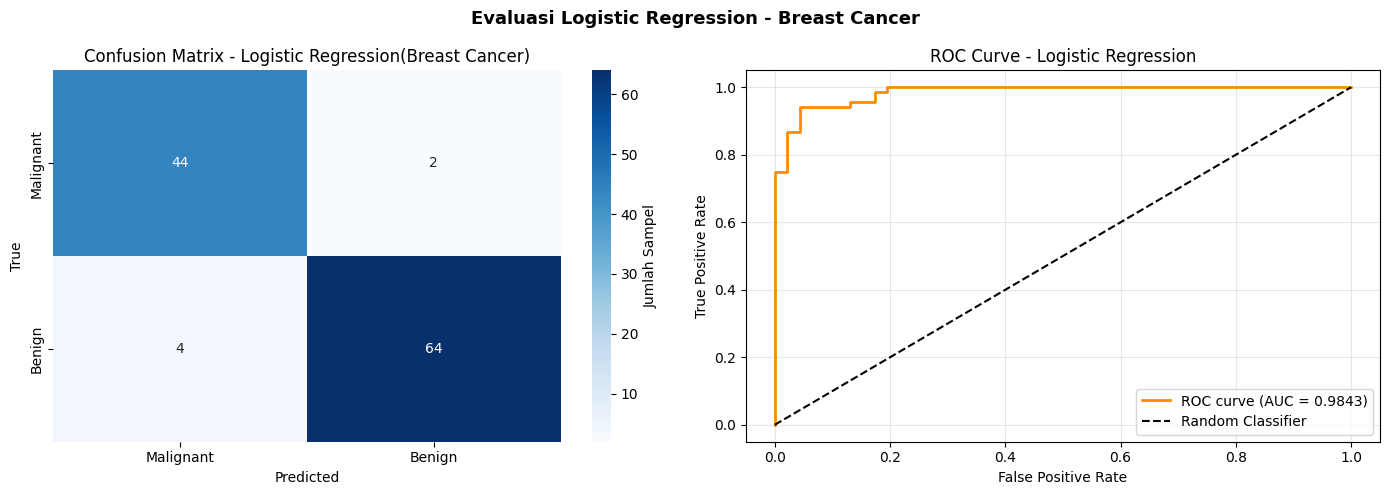

In [7]:
# Confusion matrix
cm_bc = confusion_matrix(y_bc_test, y_pred_bc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_bc, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax1, cbar_kws={'label': 'Jumlah Sampel'})
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Confusion Matrix - Logistic Regression(Breast Cancer)')

# ROC Curve
fpr_bc, tpr_bc, _ = roc_curve(y_bc_test, y_prob_bc)
roc_auc_bc = auc(fpr_bc, tpr_bc)
ax2.plot(fpr_bc, tpr_bc, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_bc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve - Logistic Regression')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Evaluasi Logistic Regression - Breast Cancer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
# Classification report sebagai DataFrame
report_bc = classification_report(
    y_bc_test, y_pred_bc, target_names=class_names, output_dict=True
)
report_df_bc = pd.DataFrame(report_bc).transpose().round(4)
print("Classification Report:")
display(report_df_bc)
print("Interpretasi:")
print("  Precision: Dari semua yang diprediksi positif, berapa persen yang benar-benar positif?")
print("  Recall:    Dari semua yang benar-benar positif, berapa persen yang berhasil terdeteksi?")
print("  F1-score:  Harmonic mean dari precision dan recall.")


Classification Report:


,precision,recall,f1-score,support
Malignant,0.9167,0.9565,0.9362,46.0000
Benign,0.9697,0.9412,0.9552,68.0000
accuracy,0.9474,0.9474,0.9474,0.9474
macro avg,0.9432,0.9488,0.9457,114.0000
weighted avg,0.9483,0.9474,0.9475,114.0000


Interpretasi:
  Precision: Dari semua yang diprediksi positif, berapa persen yang benar-benar positif?
  Recall:    Dari semua yang benar-benar positif, berapa persen yang berhasil terdeteksi?
  F1-score:  Harmonic mean dari precision dan recall.


---
## 2. Teknik Klasifikasi Multiclass

### Penjelasan Teori

Banyak masalah di dunia nyata tidak bersifat binary (0 atau 1), melainkan memiliki lebih dari dua kelas. Logistic regression dapat diperluas untuk menangani multiclass classification melalui dua strategi utama:

**1. One-vs-Rest (OvR) - juga dikenal sebagai One-vs-All:**
Melatih satu classifier binary untuk setiap kelas, di mana kelas tersebut diperlakukan sebagai kelas positif dan semua kelas lainnya sebagai kelas negatif. Saat prediksi, classifier dengan confidence score tertinggi menentukan kelas prediksi.
- Cocok untuk: dataset besar karena komputasinya paralel.
- Di scikit-learn: `solver='liblinear'` menggunakan OvR secara default.

**2. Multinomial Logistic Regression (SoftMax Regression):**
Secara langsung memodelkan probabilitas setiap kelas menggunakan **SoftMax function**, yang memastikan semua probabilitas kelas berjumlah 1. Lebih cocok ketika kelas bersifat mutually exclusive (tidak tumpang tindih).
- Di scikit-learn: `multi_class='multinomial'` dengan `solver='lbfgs'`.

> **Catatan scikit-learn:** Sejak versi 1.7, argument `multi_class` akan dihapus dan pendekatan multinomial akan selalu digunakan ketika jumlah kelas >= 3.

**Macro vs Weighted Average:**
- **Macro average:** Rata-rata metrik tanpa memperhatikan jumlah sampel per kelas. Setiap kelas diberi bobot sama.
- **Weighted average:** Rata-rata metrik dengan bobot berdasarkan jumlah sampel per kelas. Lebih representatif untuk dataset tidak seimbang.


In [10]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset (3 kelas)
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
feature_names_iris = iris.feature_names

X_ir_train, X_ir_test, y_ir_train, y_ir_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=2024
)

print(f"Dataset Iris - 3 kelas: {iris.target_names}")
print(f"Training: {X_ir_train.shape}, Testing: {X_ir_test.shape}")


Dataset Iris - 3 kelas: ['setosa' 'versicolor' 'virginica']
Training: (105, 4), Testing: (45, 4)


In [11]:
# Model 1: One-vs-Rest (OvR)
ovr_model = LogisticRegression(solver='liblinear', random_state=2024)
ovr_model.fit(X_ir_train, y_ir_train)
y_pred_ovr = ovr_model.predict(X_ir_test)
acc_ovr = accuracy_score(y_ir_test, y_pred_ovr)

# Model 2: Multinomial Logistic Regression
multi_model = LogisticRegression(
    multi_class='multinomial', solver='lbfgs',
    max_iter=1000, random_state=2024
)
multi_model.fit(X_ir_train, y_ir_train)
y_pred_multi = multi_model.predict(X_ir_test)
acc_multi = accuracy_score(y_ir_test, y_pred_multi)

print(f"One-vs-Rest (OvR) Accuracy:     {acc_ovr:.4f}")
print(f"Multinomial Accuracy:            {acc_multi:.4f}")


One-vs-Rest (OvR) Accuracy:     0.9556
Multinomial Accuracy:            0.9333


In [13]:
# Classification reports untuk kedua pendekatan
report_ovr   = pd.DataFrame(
    classification_report(y_ir_test, y_pred_ovr, target_names=iris.target_names, output_dict=True)
).transpose().round(4)
report_multi = pd.DataFrame(
    classification_report(y_ir_test, y_pred_multi, target_names=iris.target_names, output_dict=True)
).transpose().round(4)

print("Classification Report - One-vs-Rest:")
display(report_ovr)
print("Classification Report - Multinomial:")
display(report_multi)


Classification Report - One-vs-Rest:


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,18.0000
versicolor,0.9167,0.9167,0.9167,12.0000
virginica,0.9333,0.9333,0.9333,15.0000
accuracy,0.9556,0.9556,0.9556,0.9556
macro avg,0.9500,0.9500,0.9500,45.0000
weighted avg,0.9556,0.9556,0.9556,45.0000


Classification Report - Multinomial:


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,18.0000
versicolor,0.8462,0.9167,0.8800,12.0000
virginica,0.9286,0.8667,0.8966,15.0000
accuracy,0.9333,0.9333,0.9333,0.9333
macro avg,0.9249,0.9278,0.9255,45.0000
weighted avg,0.9352,0.9333,0.9335,45.0000


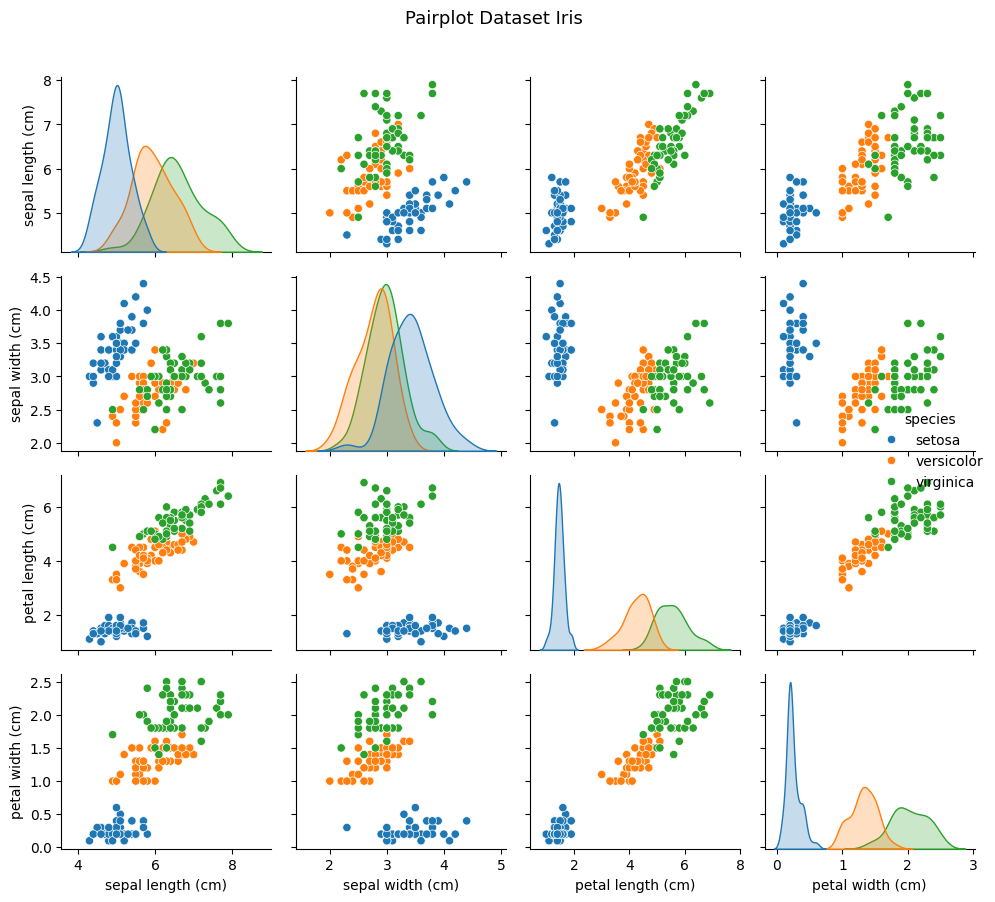

Pengamatan: Petal length dan petal width sangat informatif untuk memisahkan ketiga kelas.


In [14]:
# Pairplot untuk eksplorasi data Iris
df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)
df_iris['species'] = pd.Categorical.from_codes(
    y_iris, categories=iris.target_names
)

g = sns.pairplot(df_iris, hue='species', diag_kind='kde', height=2.2)
g.fig.suptitle('Pairplot Dataset Iris', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print("Pengamatan: Petal length dan petal width sangat informatif untuk memisahkan ketiga kelas.")


---
## 3. Regularisasi dalam Logistic Regression

### Penjelasan Teori

Seperti pada linear regression, regularisasi dalam logistic regression bertujuan mencegah overfitting dengan menambahkan penalty ke fungsi loss. Parameter `C` dalam scikit-learn adalah **kebalikan dari alpha** (kekuatan regularisasi):

- **C besar** (misalnya, C=100): Regularisasi lemah, model lebih kompleks (berisiko overfit).
- **C kecil** (misalnya, C=0.001): Regularisasi kuat, model lebih sederhana (berisiko underfit).

Formula: `C = 1 / alpha`

**Pilihan penalty dalam `LogisticRegression()`:**
- `penalty='l2'` (Ridge, default): Shrinks koefisien, semua fitur dipertahankan.
- `penalty='l1'` (Lasso): Dapat membuat koefisien menjadi 0, melakukan feature selection otomatis.
- `penalty='elasticnet'`: Kombinasi L1 dan L2 (memerlukan `solver='saga'`).
- `penalty=None`: Tanpa regularisasi (ekuivalen dengan C sangat besar).

**Pilihan solver yang kompatibel:**
- `liblinear`: Mendukung L1 dan L2, cocok untuk dataset kecil.
- `lbfgs`, `newton-cg`, `sag`: Hanya L2, cocok untuk dataset besar atau multiclass.
- `saga`: Mendukung L1, L2, dan ElasticNet.


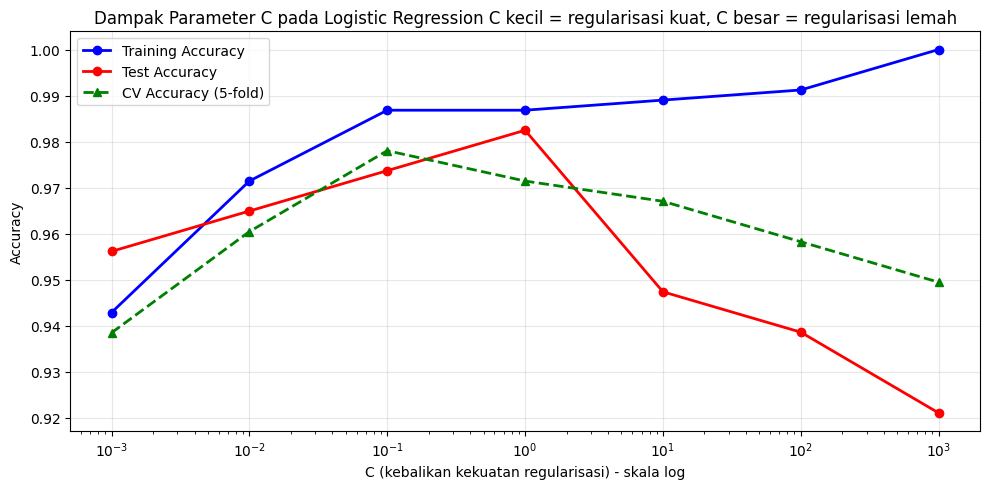

In [16]:
# Dampak nilai C pada performa (bias-variance trade-off di logistic regression)
from sklearn.model_selection import cross_val_score

C_values = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000]
train_scores_c, test_scores_c, cv_scores_c = [], [], []

# Gunakan Breast Cancer dataset dengan standardisasi
scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=2024
)

for C in C_values:
    lr_c = LogisticRegression(C=C, penalty='l2', solver='liblinear',
                               max_iter=10000, random_state=2024)
    lr_c.fit(X_bc_tr, y_bc_tr)
    train_scores_c.append(lr_c.score(X_bc_tr, y_bc_tr))
    test_scores_c.append(lr_c.score(X_bc_te, y_bc_te))
    cv_s = cross_val_score(lr_c, X_bc_tr, y_bc_tr, cv=5)
    cv_scores_c.append(cv_s.mean())

plt.figure(figsize=(10, 5))
plt.semilogx(C_values, train_scores_c, 'b-o', linewidth=2, label='Training Accuracy')
plt.semilogx(C_values, test_scores_c,  'r-o', linewidth=2, label='Test Accuracy')
plt.semilogx(C_values, cv_scores_c,    'g--^', linewidth=2, label='CV Accuracy (5-fold)')
plt.xlabel('C (kebalikan kekuatan regularisasi) - skala log')
plt.ylabel('Accuracy')
plt.title('Dampak Parameter C pada Logistic Regression C kecil = regularisasi kuat, C besar = regularisasi lemah')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:
# Perbandingan L1 vs L2 regularization
from sklearn.pipeline import Pipeline

configs = {
    'L2 (Ridge), C=0.1': LogisticRegression(penalty='l2', C=0.1, solver='liblinear', max_iter=10000),
    'L2 (Ridge), C=1.0': LogisticRegression(penalty='l2', C=1.0, solver='liblinear', max_iter=10000),
    'L1 (Lasso), C=0.1': LogisticRegression(penalty='l1', C=0.1, solver='liblinear', max_iter=10000),
    'L1 (Lasso), C=1.0': LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=10000),
}

reg_results = []
for name, lr_model in configs.items():
    pipe_reg = Pipeline([
        ('scaler', StandardScaler()),
        ('model', lr_model)
    ])
    pipe_reg.fit(X_bc_train, y_bc_train)
    y_p = pipe_reg.predict(X_bc_test)
    n_zero = np.sum(pipe_reg.named_steps['model'].coef_[0] == 0)
    reg_results.append({
        'Konfigurasi': name,
        'Accuracy':    round(accuracy_score(y_bc_test, y_p), 4),
        'Koef = 0':    n_zero,
        'Koef != 0':   len(feature_names_bc) - n_zero
    })

reg_df = pd.DataFrame(reg_results)
print("Perbandingan L1 vs L2 Regularization (Breast Cancer):")
display(reg_df)
print("L1 (Lasso) melakukan feature selection otomatis.")
print("L2 (Ridge) mempertahankan semua fitur tapi mengecilkan koefisiennya.")


Perbandingan L1 vs L2 Regularization (Breast Cancer):


,Konfigurasi,Accuracy,Koef = 0,Koef != 0
0,"L2 (Ridge), C=0.1",0.9737,0,30
1,"L2 (Ridge), C=1.0",0.9737,0,30
2,"L1 (Lasso), C=0.1",0.9649,22,8
3,"L1 (Lasso), C=1.0",0.9649,16,14


L1 (Lasso) melakukan feature selection otomatis.
L2 (Ridge) mempertahankan semua fitur tapi mengecilkan koefisiennya.


---
## 4. Konsep Multilabel Classification

### Penjelasan Teori

**Multilabel classification** adalah ekstensi dari multiclass classification di mana setiap sampel dapat memiliki **lebih dari satu label** secara bersamaan. Ini berbeda dari multiclass di mana setiap sampel hanya memiliki satu kelas.

**Contoh nyata multilabel:**
- Sebuah artikel berita bisa memiliki label "Politik" DAN "Ekonomi" sekaligus.
- Sebuah gambar bisa mengandung "Anjing" DAN "Pantai" sekaligus.
- Seorang pasien bisa didiagnosis dengan "Diabetes" DAN "Hipertensi" sekaligus.

**Pendekatan untuk multilabel classification dalam scikit-learn:**

1. **`MultiOutputClassifier`:** Melatih satu classifier terpisah untuk setiap label. Sederhana dan efektif.

2. **`ClassifierChain`:** Melatih classifier secara berurutan, di mana prediksi label sebelumnya digunakan sebagai fitur untuk label berikutnya. Menangkap korelasi antar label.

**Metrik evaluasi untuk multilabel:**
- **`hamming_loss`:** Proporsi label yang salah prediksi. Semakin kecil, semakin baik.
- **`jaccard_score`:** Interseksi dibagi union antara label prediksi dan aktual.
- `classification_report` dengan argumen `zero_division=0`.


In [19]:
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.metrics import hamming_loss, jaccard_score
from sklearn.datasets import make_multilabel_classification

# Buat dataset multilabel sintetis
X_ml, y_ml = make_multilabel_classification(
    n_samples=1000, n_features=20, n_classes=4,
    n_labels=2, random_state=2024
)

X_ml_train, X_ml_test, y_ml_train, y_ml_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=2024
)

label_names = [f'Label_{i}' for i in range(y_ml.shape[1])]
print(f"Shape X: {X_ml.shape}")
print(f"Shape y: {y_ml.shape} (multilabel - setiap baris bisa punya beberapa label)")
print(f"Contoh 5 baris label:")
display(pd.DataFrame(y_ml[:5], columns=label_names))


Shape X: (1000, 20)
Shape y: (1000, 4) (multilabel - setiap baris bisa punya beberapa label)
Contoh 5 baris label:


,Label_0,Label_1,Label_2,Label_3
0,1,1,0,0
1,1,0,1,0
2,0,1,1,0
3,1,1,1,0
4,0,0,0,0


In [20]:
# Pendekatan 1: MultiOutputClassifier
from sklearn.linear_model import LogisticRegression

base_lr = LogisticRegression(max_iter=1000, random_state=2024)

multi_out = MultiOutputClassifier(base_lr)
multi_out.fit(X_ml_train, y_ml_train)
y_pred_mo = multi_out.predict(X_ml_test)

# Pendekatan 2: ClassifierChain
chain = ClassifierChain(base_lr, order='random', random_state=2024)
chain.fit(X_ml_train, y_ml_train)
y_pred_chain = chain.predict(X_ml_test)

# Evaluasi
hl_mo    = hamming_loss(y_ml_test, y_pred_mo)
hl_chain = hamming_loss(y_ml_test, y_pred_chain)
js_mo    = jaccard_score(y_ml_test, y_pred_mo, average='samples')
js_chain = jaccard_score(y_ml_test, y_pred_chain, average='samples')

print("Perbandingan Pendekatan Multilabel Classification:")
print(f"{'Metrik':<25} {'MultiOutputClassifier':>22} {'ClassifierChain':>18}")
print("-" * 68)
print(f"{'Hamming Loss (rendah=baik)':<25} {hl_mo:>22.4f} {hl_chain:>18.4f}")
print(f"{'Jaccard Score (tinggi=baik)':<25} {js_mo:>22.4f} {js_chain:>18.4f}")


Perbandingan Pendekatan Multilabel Classification:
Metrik                     MultiOutputClassifier    ClassifierChain
--------------------------------------------------------------------
Hamming Loss (rendah=baik)                 0.2300             0.2250
Jaccard Score (tinggi=baik)                 0.5887             0.5842


---
## 5. Metrik Evaluasi Model Klasifikasi

### Penjelasan Teori

Pemilihan metrik evaluasi yang tepat sangat penting untuk menilai performa model secara akurat dan bermakna. Mengandalkan hanya satu metrik (terutama accuracy) bisa sangat menyesatkan, terutama untuk dataset yang tidak seimbang.

**Komponen Confusion Matrix:**
- **True Positive (TP):** Prediksi positif yang benar.
- **True Negative (TN):** Prediksi negatif yang benar.
- **False Positive (FP):** Prediksi positif yang salah (Type I Error).
- **False Negative (FN):** Prediksi negatif yang salah (Type II Error).

**Metrik dari Confusion Matrix:**

| Metrik | Formula | Kapan Digunakan |
|--------|---------|-----------------|
| Accuracy | (TP+TN) / (TP+TN+FP+FN) | Data seimbang |
| Precision | TP / (TP+FP) | FP sangat merugikan |
| Recall (Sensitivity) | TP / (TP+FN) | FN sangat merugikan |
| F1-Score | 2*(P*R) / (P+R) | Keseimbangan P dan R |
| Specificity | TN / (TN+FP) | Menilai kemampuan mendeteksi negatif |

**ROC Curve dan AUC:**
- **ROC (Receiver Operating Characteristic):** Plot TPR vs FPR pada berbagai threshold decision.
- **AUC (Area Under Curve):** Semakin dekat ke 1, semakin baik kemampuan diskriminasi model.
- AUC = 0.5: Model tidak lebih baik dari random guess.
- AUC = 1.0: Model sempurna.


In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline komprehensif: scaler + logistic regression
full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000, C=1.0, random_state=2024))
])

full_pipeline.fit(X_bc_train, y_bc_train)
y_pred_full = full_pipeline.predict(X_bc_test)
y_prob_full = full_pipeline.predict_proba(X_bc_test)[:, 1]

# Hitung semua metrik
acc   = accuracy_score(y_bc_test, y_pred_full)
prec  = precision_score(y_bc_test, y_pred_full)
rec   = recall_score(y_bc_test, y_pred_full)
f1    = f1_score(y_bc_test, y_pred_full)
roc_auc = roc_auc_score(y_bc_test, y_prob_full)

print("Semua Metrik Evaluasi - Logistic Regression (Breast Cancer):")
print(f"  Accuracy:   {acc:.4f}")
print(f"  Precision:  {prec:.4f}  (dari prediksi Benign, berapa % benar-benar Benign?)")
print(f"  Recall:     {rec:.4f}  (dari semua Benign aktual, berapa % terdeteksi?)")
print(f"  F1-Score:   {f1:.4f}  (harmonic mean Precision & Recall)")
print(f"  ROC-AUC:    {roc_auc:.4f}  (kemampuan diskriminasi model)")


Semua Metrik Evaluasi - Logistic Regression (Breast Cancer):
  Accuracy:   0.9825
  Precision:  1.0000  (dari prediksi Benign, berapa % benar-benar Benign?)
  Recall:     0.9706  (dari semua Benign aktual, berapa % terdeteksi?)
  F1-Score:   0.9851  (harmonic mean Precision & Recall)
  ROC-AUC:    0.9997  (kemampuan diskriminasi model)


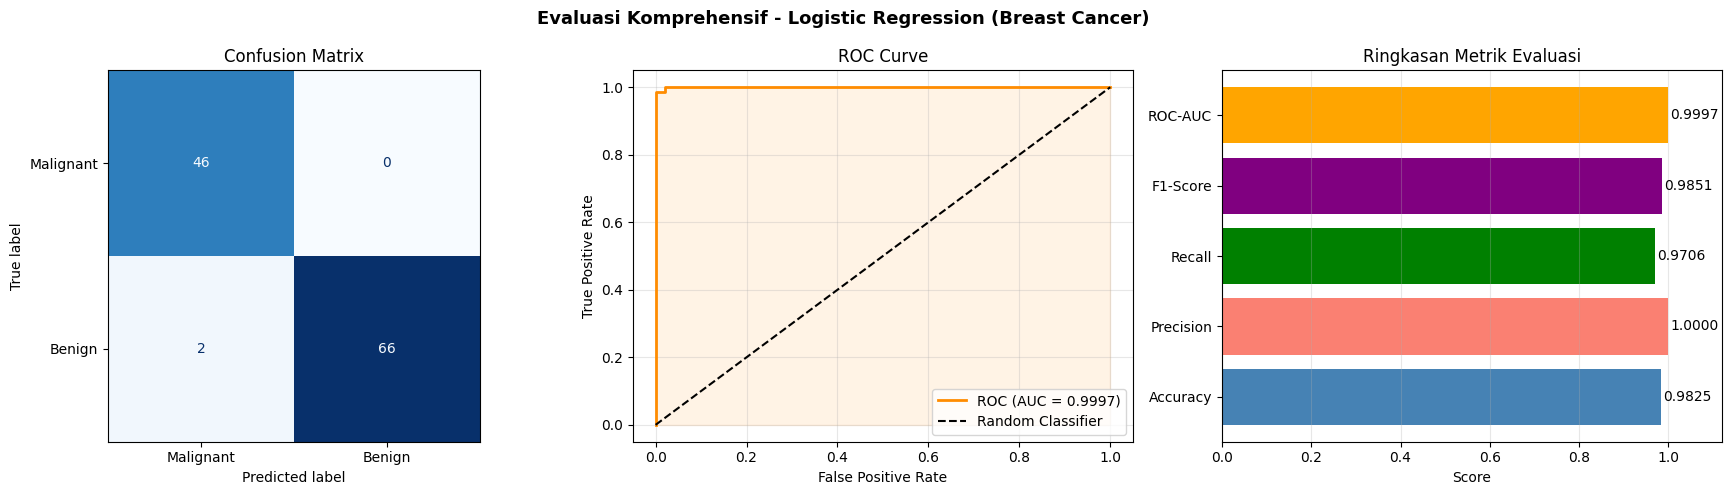

In [22]:
# Visualisasi komprehensif semua metrik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Confusion Matrix
cm_full = confusion_matrix(y_bc_test, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_full, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# Panel 2: ROC Curve
fpr_f, tpr_f, thresholds_f = roc_curve(y_bc_test, y_prob_full)
axes[1].plot(fpr_f, tpr_f, color='darkorange', lw=2,
             label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr_f, tpr_f, alpha=0.1, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Panel 3: Metrik Bar Chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_values = [acc, prec, rec, f1, roc_auc]
bars = axes[2].barh(metric_names, metric_values,
                    color=['steelblue', 'salmon', 'green', 'purple', 'orange'])
for bar, val in zip(bars, metric_values):
    axes[2].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center')
axes[2].set_xlim(0, 1.12)
axes[2].set_xlabel('Score')
axes[2].set_title('Ringkasan Metrik Evaluasi')
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Evaluasi Komprehensif - Logistic Regression (Breast Cancer)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


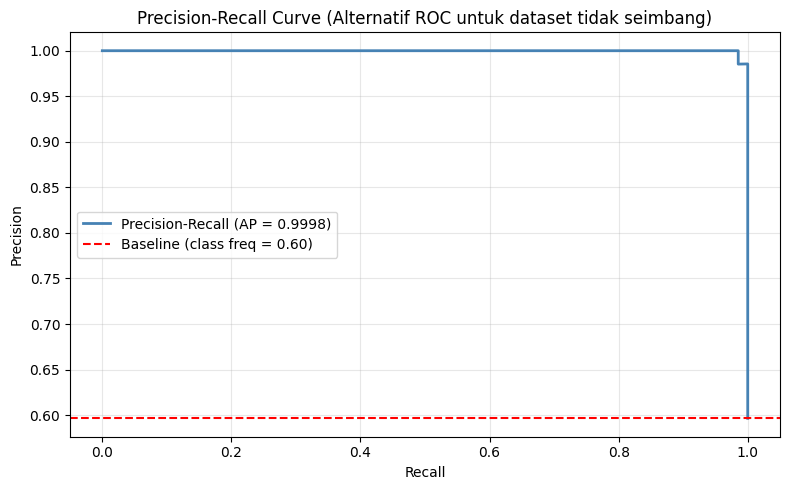

In [24]:
# Precision-Recall Curve (berguna untuk imbalanced dataset)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_bc_test, y_prob_full)
avg_precision = average_precision_score(y_bc_test, y_prob_full)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, color='steelblue', lw=2,
         label=f'Precision-Recall (AP = {avg_precision:.4f})')
plt.axhline(y_bc_test.mean(), color='red', linestyle='--',
            label=f'Baseline (class freq = {y_bc_test.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Alternatif ROC untuk dataset tidak seimbang)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6. Implementasi Komprehensif: Decision Boundary Visualization

### Deskripsi

Untuk mengkonsolidasikan semua yang dipelajari, kita akan memvisualisasikan decision boundary logistic regression pada dataset sintetis 2D. Ini membantu membangun intuisi tentang bagaimana logistic regression membuat keputusan klasifikasi di ruang fitur.


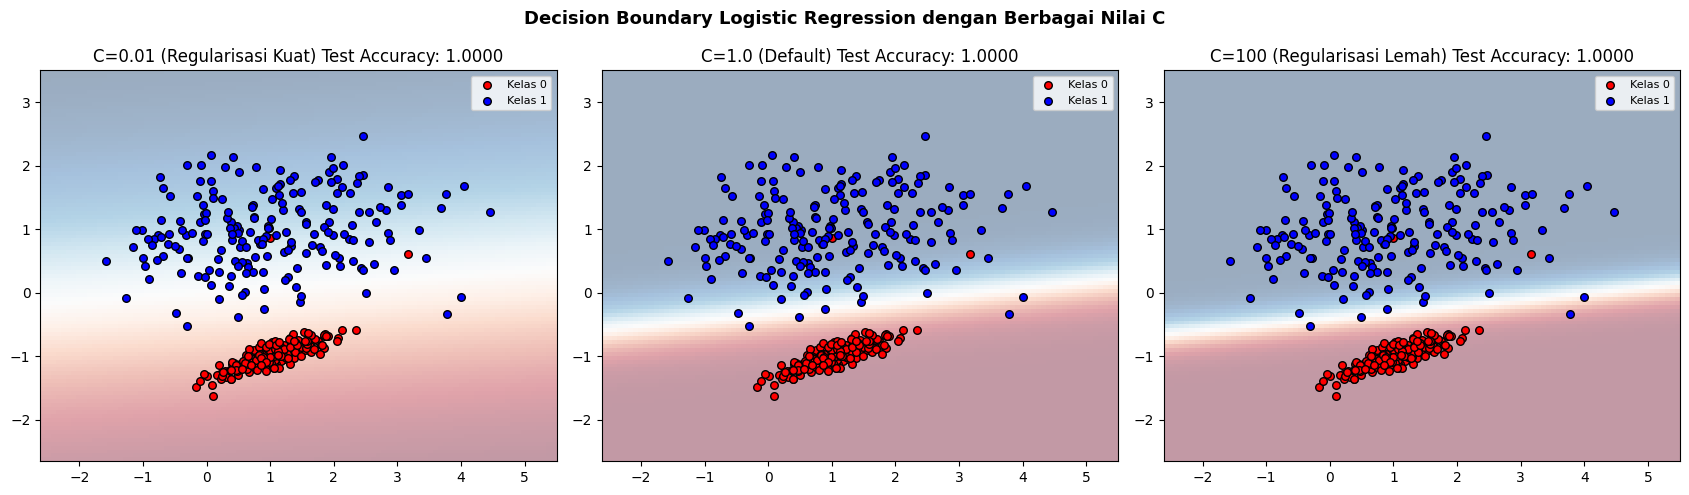

In [27]:
from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay

# Buat dataset binary classification 2D
X_2d_cl, y_2d_cl = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1,
    random_state=2024
)

X_2d_tr, X_2d_te, y_2d_tr, y_2d_te = train_test_split(
    X_2d_cl, y_2d_cl, test_size=0.2, random_state=2024
)

# Latih logistic regression dengan berbagai nilai C
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
C_demo = [0.01, 1.0, 100]
titles = ['C=0.01 (Regularisasi Kuat)', 'C=1.0 (Default)', 'C=100 (Regularisasi Lemah)']

for ax, C_val, title in zip(axes, C_demo, titles):
    lr_demo = LogisticRegression(C=C_val, random_state=2024)
    lr_demo.fit(X_2d_tr, y_2d_tr)
    acc_demo = lr_demo.score(X_2d_te, y_2d_te)

    DecisionBoundaryDisplay.from_estimator(
        lr_demo, X_2d_tr,
        response_method='predict_proba', plot_method='pcolormesh',
        cmap='RdBu', alpha=0.4, ax=ax
    )
    ax.scatter(X_2d_tr[y_2d_tr == 0, 0], X_2d_tr[y_2d_tr == 0, 1],
               color='red', edgecolor='k', s=30, label='Kelas 0')
    ax.scatter(X_2d_tr[y_2d_tr == 1, 0], X_2d_tr[y_2d_tr == 1, 1],
               color='blue', edgecolor='k', s=30, label='Kelas 1')
    ax.set_title(f'{title} Test Accuracy: {acc_demo:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Decision Boundary Logistic Regression dengan Berbagai Nilai C',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [29]:
# Latihan komprehensif: pipeline lengkap dengan GridSearchCV
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid_lr = {
    'model__C':       [0.01, 0.1, 1.0, 10.0, 100.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear']
}

pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000, random_state=2024))
])

gs_lr = GridSearchCV(
    pipeline_final, param_grid_lr,
    cv=5, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_bc_train, y_bc_train)

print("GridSearchCV - Logistic Regression (Breast Cancer):")
print(f"  Parameter terbaik: {gs_lr.best_params_}")
print(f"  CV ROC-AUC terbaik: {gs_lr.best_score_:.4f}")

# Evaluasi model terbaik
best_lr = gs_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_bc_test)
y_prob_best_lr = best_lr.predict_proba(X_bc_test)[:, 1]

print(f"Performa model terbaik pada test set:")
print(f"  Accuracy:  {accuracy_score(y_bc_test, y_pred_best_lr):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_bc_test, y_prob_best_lr):.4f}")
print(f"  F1-Score:  {f1_score(y_bc_test, y_pred_best_lr):.4f}")


GridSearchCV - Logistic Regression (Breast Cancer):
  Parameter terbaik: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
  CV ROC-AUC terbaik: 0.9944
Performa model terbaik pada test set:
  Accuracy:  0.9649
  ROC-AUC:   0.9872
  F1-Score:  0.9701


---
## Ringkasan Chapter 6

| Konsep | Kelas/Fungsi scikit-learn | Deskripsi |
|--------|--------------------------|-----------|
| Binary Classification | `LogisticRegression()` | Prediksi 2 kelas menggunakan sigmoid function |
| One-vs-Rest (OvR) | `LogisticRegression(solver='liblinear')` | Satu classifier binary per kelas |
| Multinomial | `LogisticRegression(multi_class='multinomial')` | SoftMax untuk semua kelas sekaligus |
| L2 Regularization | `penalty='l2'` | Shrink koefisien, semua fitur dipertahankan |
| L1 Regularization | `penalty='l1'` | Feature selection otomatis (koef bisa = 0) |
| Multilabel (independent) | `MultiOutputClassifier()` | Satu classifier per label |
| Multilabel (chained) | `ClassifierChain()` | Label sebelumnya sebagai fitur label berikutnya |
| Confusion Matrix | `confusion_matrix()` | Distribusi TP, TN, FP, FN |
| ROC-AUC | `roc_auc_score()` | Kemampuan diskriminasi model |
| Precision-Recall | `precision_recall_curve()` | Alternatif ROC untuk data tidak seimbang |

### Poin Kunci untuk Diingat:

1. **Logistic regression adalah algoritma klasifikasi**, bukan regresi. Ia memprediksi probabilitas kelas menggunakan sigmoid function.

2. **Sigmoid function** mengubah kombinasi linear fitur menjadi probabilitas antara 0 dan 1. Threshold default adalah 0.5, tapi bisa disesuaikan.

3. **OvR vs Multinomial:** OvR melatih classifier binary terpisah per kelas; Multinomial memodelkan semua kelas sekaligus dengan SoftMax. Multinomial lebih tepat untuk kelas yang mutually exclusive.

4. **Parameter C adalah kebalikan kekuatan regularisasi:** C kecil = regularisasi kuat (model sederhana), C besar = regularisasi lemah (model kompleks).

5. **Pilih metrik evaluasi yang tepat:** Accuracy bisa menyesatkan untuk dataset tidak seimbang. Gunakan Precision, Recall, F1, atau ROC-AUC tergantung konteks bisnis.

6. **Recall vs Precision trade-off:** Pada deteksi penyakit, Recall lebih penting (jangan sampai ada kasus positif yang terlewat). Pada deteksi spam, Precision lebih penting (jangan sampai email penting terhapus).

7. **Selalu standardisasi fitur** sebelum logistic regression, terutama ketika menggunakan regularisasi, agar penalty diterapkan secara adil ke semua fitur.
